<a href="https://colab.research.google.com/github/vikashkumar97983282-glitch/Deep_Learning/blob/main/CIFAR_Datasets_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)  # (50000, 32, 32, 3)
print(x_test.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3105s 18us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
X_train = x_train.astype('float32')/255.0
X_test = x_test.astype('float32')/255.0

In [ ]:
cnn = Sequential()

cnn.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))

cnn.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))

cnn.add(Flatten())

cnn.add(Dense(256,activation='relu'))
cnn.add(Dropout(0.5))
# cnn.add(Dense(32,activation='relu'))
cnn.add(Dense(10,activation='softmax'))

In [ ]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,042 (2.33 MB)

 Trainable params: 612,042 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = cnn.fit(X_train,y_train,epochs=10,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.4183 - loss: 1.5968 - val_accuracy: 0.5591 - val_loss: 1.2541
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - accuracy: 0.5511 - loss: 1.2688 - val_accuracy: 0.6079 - val_loss: 1.1249
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.5961 - loss: 1.1466 - val_accuracy: 0.6374 - val_loss: 1.0457
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.6213 - loss: 1.0759 - val_accuracy: 0.6716 - val_loss: 0.9652
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6405 - loss: 1.0195 - val_accuracy: 0.6754 - val_loss: 0.9310
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 48ms/step - accuracy: 0.6541 - loss: 0.9763 - val_accuracy: 0.7000 - val_loss: 0.8981
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6681 - loss: 0.9445 - val_accuracy: 0.7032 - val_loss: 0.8656
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6831 -

In [ ]:
cnn.evaluate(X_test,y_test,verbose=0)[1]

0.7139999866485596

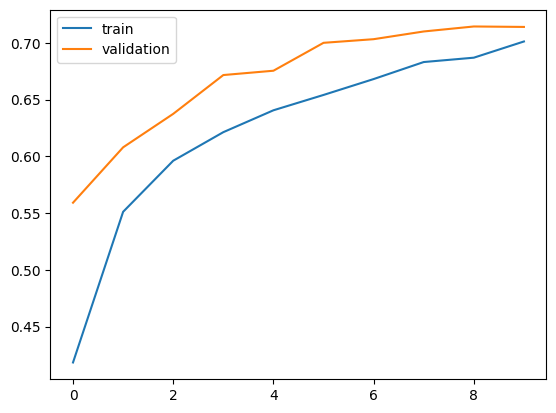

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

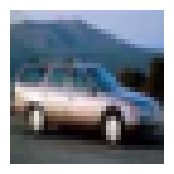

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))   # small figure size
plt.imshow(x_train[4])
plt.axis('off')
plt.show()

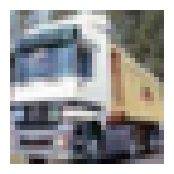

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[1])
plt.axis('off')
plt.show()

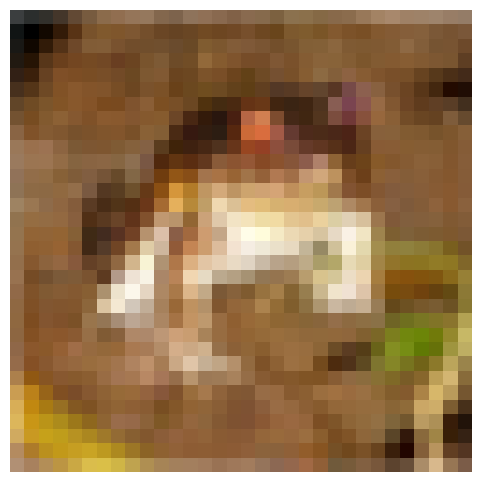

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(x_train[0], interpolation='nearest')
plt.axis('off')
plt.show()

In [ ]:
cnn.predict(X_test[0].reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


array([[0.01260814, 0.00209403, 0.01999246, 0.7213247 , 0.00664137,
        0.12736942, 0.04808736, 0.00840687, 0.04891166, 0.00456402]],
      dtype=float32)

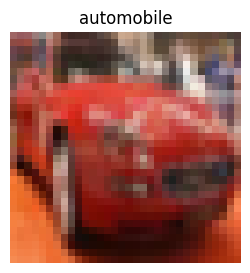

In [ ]:
import matplotlib.pyplot as plt

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

idx = 5

plt.figure(figsize=(3,3))
plt.imshow(x_train[idx])
plt.title(classes[y_train[idx][0]])
plt.axis('off')
plt.show()

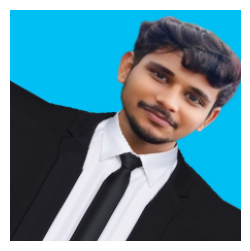

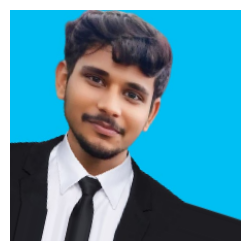

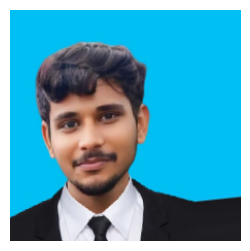

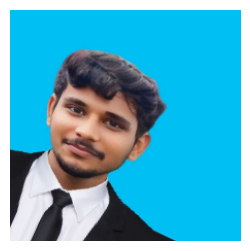

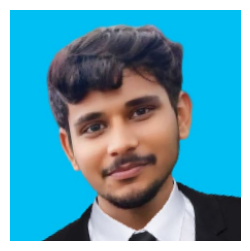

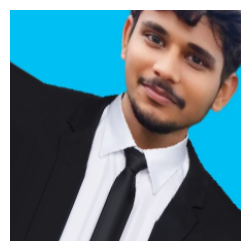

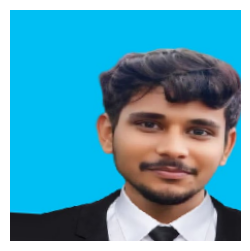

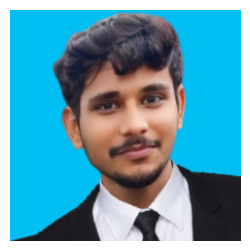

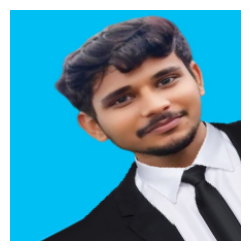

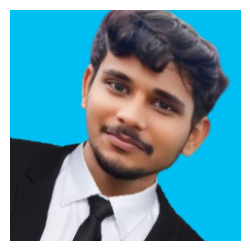

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

# Load image
img = load_img("/content/vikashgitimage.jpeg", target_size=(224,224))
img = img_to_array(img)

# Convert to batch format
img = np.expand_dims(img, axis=0)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate augmented images
i = 0
for batch in datagen.flow(img, batch_size=1):
    plt.figure(figsize=(3,3))
    plt.imshow(batch[0].astype('uint8'))
    plt.axis('off')
    plt.show()
    print(sep='')

    i += 1
    if i == 10:  # Generate 5 images
        break

In [ ]:
datagen.flow(
    img,
    batch_size=1,
    save_to_dir='augmented_images',
    save_prefix='img',
    save_format='jpg'
)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

history = cnn.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.6072 - loss: 1.1348 - val_accuracy: 0.7120 - val_loss: 0.8328
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 63ms/step - accuracy: 0.6180 - loss: 1.1009 - val_accuracy: 0.7071 - val_loss: 0.8445
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6200 - loss: 1.0902 - val_accuracy: 0.6915 - val_loss: 0.8883
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6270 - loss: 1.0714 - val_accuracy: 0.7003 - val_loss: 0.8826
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 63ms/step - accuracy: 0.6278 - loss: 1.0650 - val_accuracy: 0.7120 - val_loss: 0.8370
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 63ms/step - accuracy: 0.6327 - loss: 1.0520 - val_accuracy: 0.7178 - val_loss: 0.8137
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 64ms/step - accuracy: 0.6361 - loss: 1.0424 - val_accuracy: 0.7044 - val_loss: 0.8629
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 63ms/step - accuracy: 0.64

In [ ]:
cnn.evaluate(X_test,y_test,verbose=0)[1]

0.7427999973297119

In [ ]:
import cv2

img = cv2.imread("/content/vikashgitimage.jpeg")

print(img.shape)

(531, 413, 3)


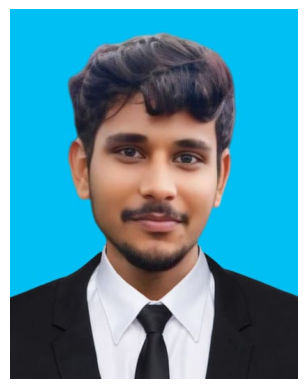

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/vikashgitimage.jpeg")

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
